<a href="https://colab.research.google.com/github/Pradeep1694/Pradeep_Assignment.py/blob/main/Exploratory_Data_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(df.shape)
print(df.head(10))

(200, 6)
   order_id       city     category  order_value  delivery_days rating
0      1001  Bangalore    Groceries       4191.0           11.0      4
1      1002    Chennai    Furniture       4923.0           12.0      1
2      1003     Mumbai    Groceries       4882.0           13.0      2
3      1004  Bangalore  Electronics       1848.0           13.0      1
4      1005  Bangalore    Furniture       1645.0           12.0      1
5      1006    Chennai  Electronics      95000.0           14.0   None
6      1007     Mumbai    Furniture       4123.0            2.0      1
7      1008     Mumbai    Furniture        453.0           13.0      5
8      1009  Bangalore     Clothing       3383.0            3.0   None
9      1010      Delhi  Electronics       2757.0            2.0   None


In [14]:
#----------------Task 1 — Inspect & Handle Missing Values -------------------


print("\n shape:")
print(df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

missing = df.isnull().sum()
print("\nMissing values:")
print(missing)


print("\nMissing percentage:")
print((missing / len(df) * 100).round(2))


 shape:
(200, 6)

Columns
['order_id', 'city', 'category', 'order_value', 'delivery_days', 'rating']

Data Types:
order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object

Missing values:
order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64

Missing percentage:
order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64


           order_id       city   category   order_value  delivery_days  rating
count    200.000000        200        200    186.000000     190.000000   168.0
unique          NaN          4          4           NaN            NaN     5.0
top             NaN  Bangalore  Furniture           NaN            NaN     5.0
freq            NaN         54         61           NaN            NaN    38.0
mean    1100.500000        NaN        NaN   3707.134409       7.810526     NaN
std       57.879185        NaN        NaN   9238.438378       4.075465     NaN
min     1001.000000        NaN        NaN    204.000000       1.000000     NaN
25%     1050.750000        NaN        NaN   1512.000000       4.000000     NaN
50%     1100.500000        NaN        NaN   2934.000000       8.000000     NaN
75%     1150.250000        NaN        NaN   3987.500000      12.000000     NaN
max     1200.000000        NaN        NaN  95000.000000      14.000000     NaN


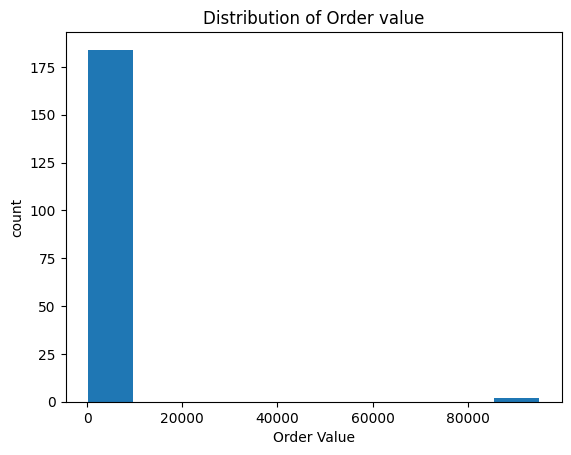

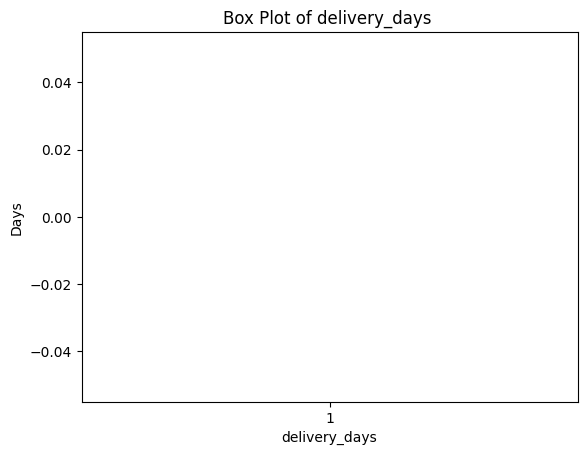

In [15]:
#-------------Task 2: Summarize & Visualize --------------
summary = df.describe(include='all')
print(summary)

#Histogram(order value)
plt.figure()
plt.hist(df["order_value"], bins = 10)
plt.title("Distribution of Order value")
plt.xlabel("Order Value")
plt.ylabel("count")
plt.show()


#box plot (delivery_days)
plt.figure()
plt.boxplot(df["delivery_days"])
plt.title("Box Plot of delivery_days ")
plt.xlabel("delivery_days")
plt.ylabel("Days")
plt.show()

               order_id  order_value  delivery_days
order_id       1.000000    -0.095503       0.004858
order_value   -0.095503     1.000000       0.141660
delivery_days  0.004858     0.141660       1.000000


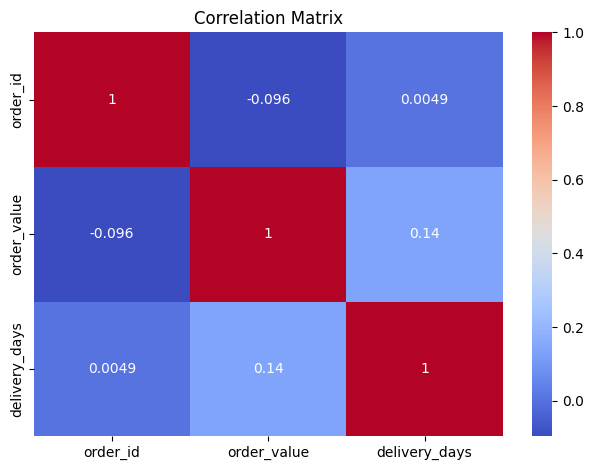

In [16]:
#--------------Task 3: Correlation Analysis-------------------
corr = df.corr(numeric_only=True)
print(corr)

plt.figure()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

order value and delivery days show weak correlation